In [3]:
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
import requests
from langchain_core.messages import BaseMessage,HumanMessage
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.graph import StateGraph,START,END

In [4]:
load_dotenv()

llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-72B-Instruct",
    task="conversational"
)

model = ChatHuggingFace(llm=llm)

c:\Users\Sreenivas Bandaru\Desktop\Langgraph\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
#tool-1
search_tool = DuckDuckGoSearchRun(region="us-en")


#tool-2
@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num

        elif operation == "sub":
            result = first_num - second_num

        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            result = first_num/second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}



#tool-3
@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=ZPKIMH8JJP5Z5QA5"
    r = requests.get(url)
    return r.json()

In [6]:
tools = [search_tool,calculator,get_stock_price]

model_with_tools = model.bind_tools(tools)

In [7]:
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage],add_messages]


def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = model_with_tools.invoke(messages)
    return {'messages': [response]}

tool_node = ToolNode(tools)

In [8]:
graph = StateGraph(ChatState)
graph.add_node('chat_node',chat_node)
graph.add_node('tools',tool_node)

graph.add_edge(START,'chat_node')
graph.add_conditional_edges('chat_node',tools_condition)


workflow = graph.compile()


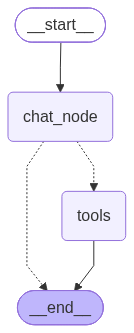

In [9]:
workflow

In [15]:
workflow.invoke({"messages":HumanMessage(content="what is the capital city of india")})

{'messages': [HumanMessage(content='what is the capital city of india', additional_kwargs={}, response_metadata={}, id='f83ea10f-2d2d-4416-a1e1-89ecc5a02c47'),
  AIMessage(content='The capital city of India is New Delhi.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 576, 'total_tokens': 585}, 'model_name': 'Qwen/Qwen2.5-72B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0ec00-218f-7e70-9410-b05e14b00e71-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 576, 'output_tokens': 9, 'total_tokens': 585})]}

In [13]:
res = workflow.invoke({"messages":HumanMessage(content="what is the multiplication of 2 and 18")})

In [14]:
res

{'messages': [HumanMessage(content='what is the multiplication of 2 and 18', additional_kwargs={}, response_metadata={}, id='61bb49d4-2519-451a-a470-e2dd57c21c9a'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'function': {'arguments': '{"first_num": 2, "second_num": 18, "operation": "mul"}', 'name': 'calculator', 'description': None}, 'id': 'call_zdJVY1Syz6PnOfDTuGDaRy5W', 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 580, 'total_tokens': 614}, 'model_name': 'Qwen/Qwen2.5-72B-Instruct', 'system_fingerprint': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0ebff-52e0-7453-943c-5dc6f64ead53-0', tool_calls=[{'name': 'calculator', 'args': {'first_num': 2, 'second_num': 18, 'operation': 'mul'}, 'id': 'call_zdJVY1Syz6PnOfDTuGDaRy5W', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 580, 'output_tokens': 34, 'total_tokens': 614}),
  ToolMessage(content='{"first_num": 2.0, "

In [16]:
type(res)

dict

In [20]:
res['messages'][-1]

ToolMessage(content='{"first_num": 2.0, "second_num": 18.0, "operation": "mul", "result": 36.0}', name='calculator', id='f2d40ab9-8698-4a80-aab7-ed039f8d8c87', tool_call_id='call_zdJVY1Syz6PnOfDTuGDaRy5W')

In [22]:
res = res['messages'][-1].content

In [23]:
res

'{"first_num": 2.0, "second_num": 18.0, "operation": "mul", "result": 36.0}'

Here the problem with the tool calling is we get the output in the json/unrefined so which causes bad user experience so we fix this in next program

we Solve the problem just by adding a single line i.e connecting the tool_node back to chat_node